<div align="center">

# Machine Learning
## Regresión Logistica
### Diagnóstico - Cáncer de Mama en Wisconsin
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 08 de Abril del 2026

<br><br><br><br><br><br><br><br><br><br>

---

## Resumen
## Resumen del Trabajo – Regresión Logística

<p style="text-align: justify">Este documento presenta el desarrollo práctico de un modelo de regresión logística aplicado al dataset Breast Cancer Wisconsin, con el objetivo de predecir si un tumor es benigno o maligno. Se incluyen todas las etapas del análisis de datos, desde la carga y limpieza del dataset, pasando por la traducción de columnas al español, hasta la preparación de variables independientes y dependientes.

<p style="text-align: justify">Se realizó la selección de las variables más relevantes utilizando los valores extremos ('_peor') de las mediciones, dado que representan los casos más significativos para la predicción del diagnóstico. Se transformó la variable 'Diagnóstico' a valores numéricos (0 = Benigno, 1 = Maligno) para adecuarla al modelo de regresión logística.

<p style="text-align: justify">Se llevaron a cabo diversas operaciones de análisis exploratorio de datos, incluyendo gráficos de dispersión, correlación entre variables y visualización de coeficientes del modelo, con el objetivo de interpretar la influencia de cada característica en la predicción del diagnóstico.

<p style="text-align: justify">El modelo fue entrenado utilizando un 80% de los datos para entrenamiento y 20% para prueba, aplicando escalamiento a las variables numéricas y estratificación para mantener la proporción de casos benignos y malignos. Se evaluó el desempeño del modelo mediante precisión, matriz de confusión y probabilidades predichas, logrando una correcta clasificación de los tumores con un alto porcentaje de exactitud.

<p style="text-align: justify">Finalmente, se visualizaron los coeficientes del modelo para identificar las variables que más impactan en la predicción, y se construyeron gráficas de correlación y mapas de calor para la matriz de confusión, facilitando la interpretación de los resultados.

<p style="text-align: justify">Este trabajo integra conceptos de machine learning, preparación de datos, análisis exploratorio y modelado predictivo, proporcionando una base sólida para aplicar regresión logística en problemas de clasificación binaria relacionados con diagnóstico médico.

</div>

## Librerias

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

from sklearn.model_selection import train_test_split #Regresión Multiple
from sklearn.datasets import load_digits #Data Sets
from sklearn.linear_model import LogisticRegression #Regresión logistica
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #Matriz de Confución
from sklearn.preprocessing import MinMaxScaler # Nos sirve para escalar los datos (Como la campana de Gaus)
from sklearn.metrics import accuracy_score #Exactitud del modelo

import plotly.express as px


In [2]:
pd.set_option("display.max_columns", None) # Mostrar todas las columnas
pd.set_option("display.max_colwidth", None)# Ajustar el ancho de las columnas (para no cortar texto)
pd.set_option("display.width", None) # Evitar que se corte horizontalmente

## Estilos para graficos de plotly

In [3]:
# Función para Generar estilos en los graficos
def Estilos(fig):
    fig.update_layout(
        template='plotly_dark',
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='#111827',
        font=dict(color='white')
    )
    
    try:
        fig.update_traces(
            marker_line_color='rgb(8,48,107)',
            marker_line_width=1.5, 
            opacity=0.7
        )
    except Exception:
        try:
            fig.update_traces(opacity=0.7)
        except:
            pass

# Función para generar los graficos por segmentos
def plt_Categoria(Columnas):
    fig = px.histogram(
        Data_Kaggle,
        x=Columnas,
        color="Diagnóstico",
        barmode="group",
        text_auto=True
    )
    Estilos(fig)
    fig.update_layout(width=600, height=400)
    fig.show()

## Datos

In [4]:
ruta_completa = os.path.join("..", "Bases", "Breast Cancer Wisconsin.csv")
Data_Kaggle = pd.read_csv(ruta_completa)


In [5]:
traduccion = {
    "id": "ID",
    "diagnosis": "Diagnóstico",
    "radius_mean": "Radio_promedio",
    "texture_mean": "Textura_promedio",
    "perimeter_mean": "Perímetro_promedio",
    "area_mean": "Área_promedio",
    "smoothness_mean": "Suavidad_promedio",
    "compactness_mean": "Compacticidad_promedio",
    "concavity_mean": "Concavidad_promedio",
    "concave points_mean": "Puntos_concavos_promedio",
    "symmetry_mean": "Simetría_promedio",
    "fractal_dimension_mean": "Dimensión_fractal_promedio",
    "radius_se": "Radio_error_estándar",
    "texture_se": "Textura_error_estándar",
    "perimeter_se": "Perímetro_error_estándar",
    "area_se": "Área_error_estándar",
    "smoothness_se": "Suavidad_error_estándar",
    "compactness_se": "Compacticidad_error_estándar",
    "concavity_se": "Concavidad_error_estándar",
    "concave points_se": "Puntos_concavos_error_estándar",
    "symmetry_se": "Simetría_error_estándar",
    "fractal_dimension_se": "Dimensión_fractal_error_estándar",
    "radius_worst": "Radio_peor",
    "texture_worst": "Textura_peor",
    "perimeter_worst": "Perímetro_peor",
    "area_worst": "Área_peor",
    "smoothness_worst": "Suavidad_peor",
    "compactness_worst": "Compacticidad_peor",
    "concavity_worst": "Concavidad_peor",
    "concave points_worst": "Puntos_concavos_peor",
    "symmetry_worst": "Simetría_peor",
    "fractal_dimension_worst": "Dimensión_fractal_peor"
}
Data_Kaggle.rename(columns=traduccion, inplace=True)

## Analisis de paso

In [6]:
No_x = {col for col in Data_Kaggle.columns if "_peor" not in col and col != "Diagnóstico"} #Definimos Datos que vamos a utilizar para no quitarlos
Data_Kaggle.drop(columns=No_x, axis=0, inplace=True) #Quitamos Datos que no vamos a utilizar
Data_Kaggle.dropna(inplace=True) #Quitamos Datos nullos
Data_Kaggle.isnull().sum() #Contamos los datos Nullos
Data_Kaggle["Diagnóstico"] = Data_Kaggle["Diagnóstico"].map({"B": "Benigno", "M": "Maligno"}) # Mapear Diagnóstico a números

## Definición de Variable Dependiente y de Variables Independientes

In [7]:
# Variable Dependiente
y = Data_Kaggle['Diagnóstico']
# Variables Independientes en el peor de los casos, Considero que estas Variables son las que llevan al extremo el modelo para ser mas exacto porque sería el _pero de los casos
x = columnas_worst = [col for col in Data_Kaggle.columns if "_peor" in col]

In [8]:
Columnas_Segmentos = Data_Kaggle.select_dtypes(include=object).columns #Obtenemos columnas de segmentos

#Recorremos los segmentos y llamamos la función de creación de graficas
for columna in Columnas_Segmentos:
    plt_Categoria(columna)

### Analisis exploratorio de los datos

In [9]:
# Obtenemos X y Y de las graficas 
Data_Kaggle_x = Data_Kaggle.drop(columns=["Diagnóstico"]) 
Data_Kaggle_y = Data_Kaggle["Diagnóstico"] 

#Unimos X y Y de nuevo para validaciones 
Data_Kaggle_Int = pd.get_dummies(Data_Kaggle_x).astype(int).copy() 
Data_Kaggle_Int["Diagnóstico"] = Data_Kaggle_y 

# Cambiamos el campo Diagnóstico a Numeros Benigno = 0 y Maligno = 1 
Data_Kaggle_Int["Diagnóstico"] = Data_Kaggle_Int["Diagnóstico"].str.strip().replace().map({"Maligno": 1, "Benigno": 0}).fillna(0).astype(int)

corr = Data_Kaggle_Int.corr(numeric_only=True)["Diagnóstico"].sort_values(ascending=True)

# Convertimos a DataFrame
df_corr = corr.reset_index()
df_corr.columns = ["Variable", "Correlacion"]

# Creamos columna Color
df_corr["Color"] = df_corr["Correlacion"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

fig = px.bar(
    df_corr,
    x="Correlacion",
    y="Variable",
    orientation="h",
    color="Color",
    color_discrete_map={"Negativo": "lightred", "Positivo": "lightblue"},
    labels={"Correlacion":"Correlación con Diagnóstico", "Variable":"Variables"},
    title="Correlación de variables con Diagnóstico"
)

fig.update_layout(
    width=890,
    height=800,
    yaxis=dict(showticklabels=False)
)

# Etiquetas centradas en x=0
for var in df_corr["Variable"]:
    fig.add_annotation(
        x=0,
        y=var,
        text=var,
        showarrow=False,
        font=dict(color="white", size=12),
        xanchor="center"
    )

Estilos(fig)
fig.show()

C:\Users\jawar\AppData\Local\Temp\ipykernel_7408\3115018535.py:10: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  Data_Kaggle_Int["Diagnóstico"] = Data_Kaggle_Int["Diagnóstico"].str.strip().replace().map({"Maligno": 1, "Benigno": 0}).fillna(0).astype(int)


<Figure size 1000x600 with 0 Axes>

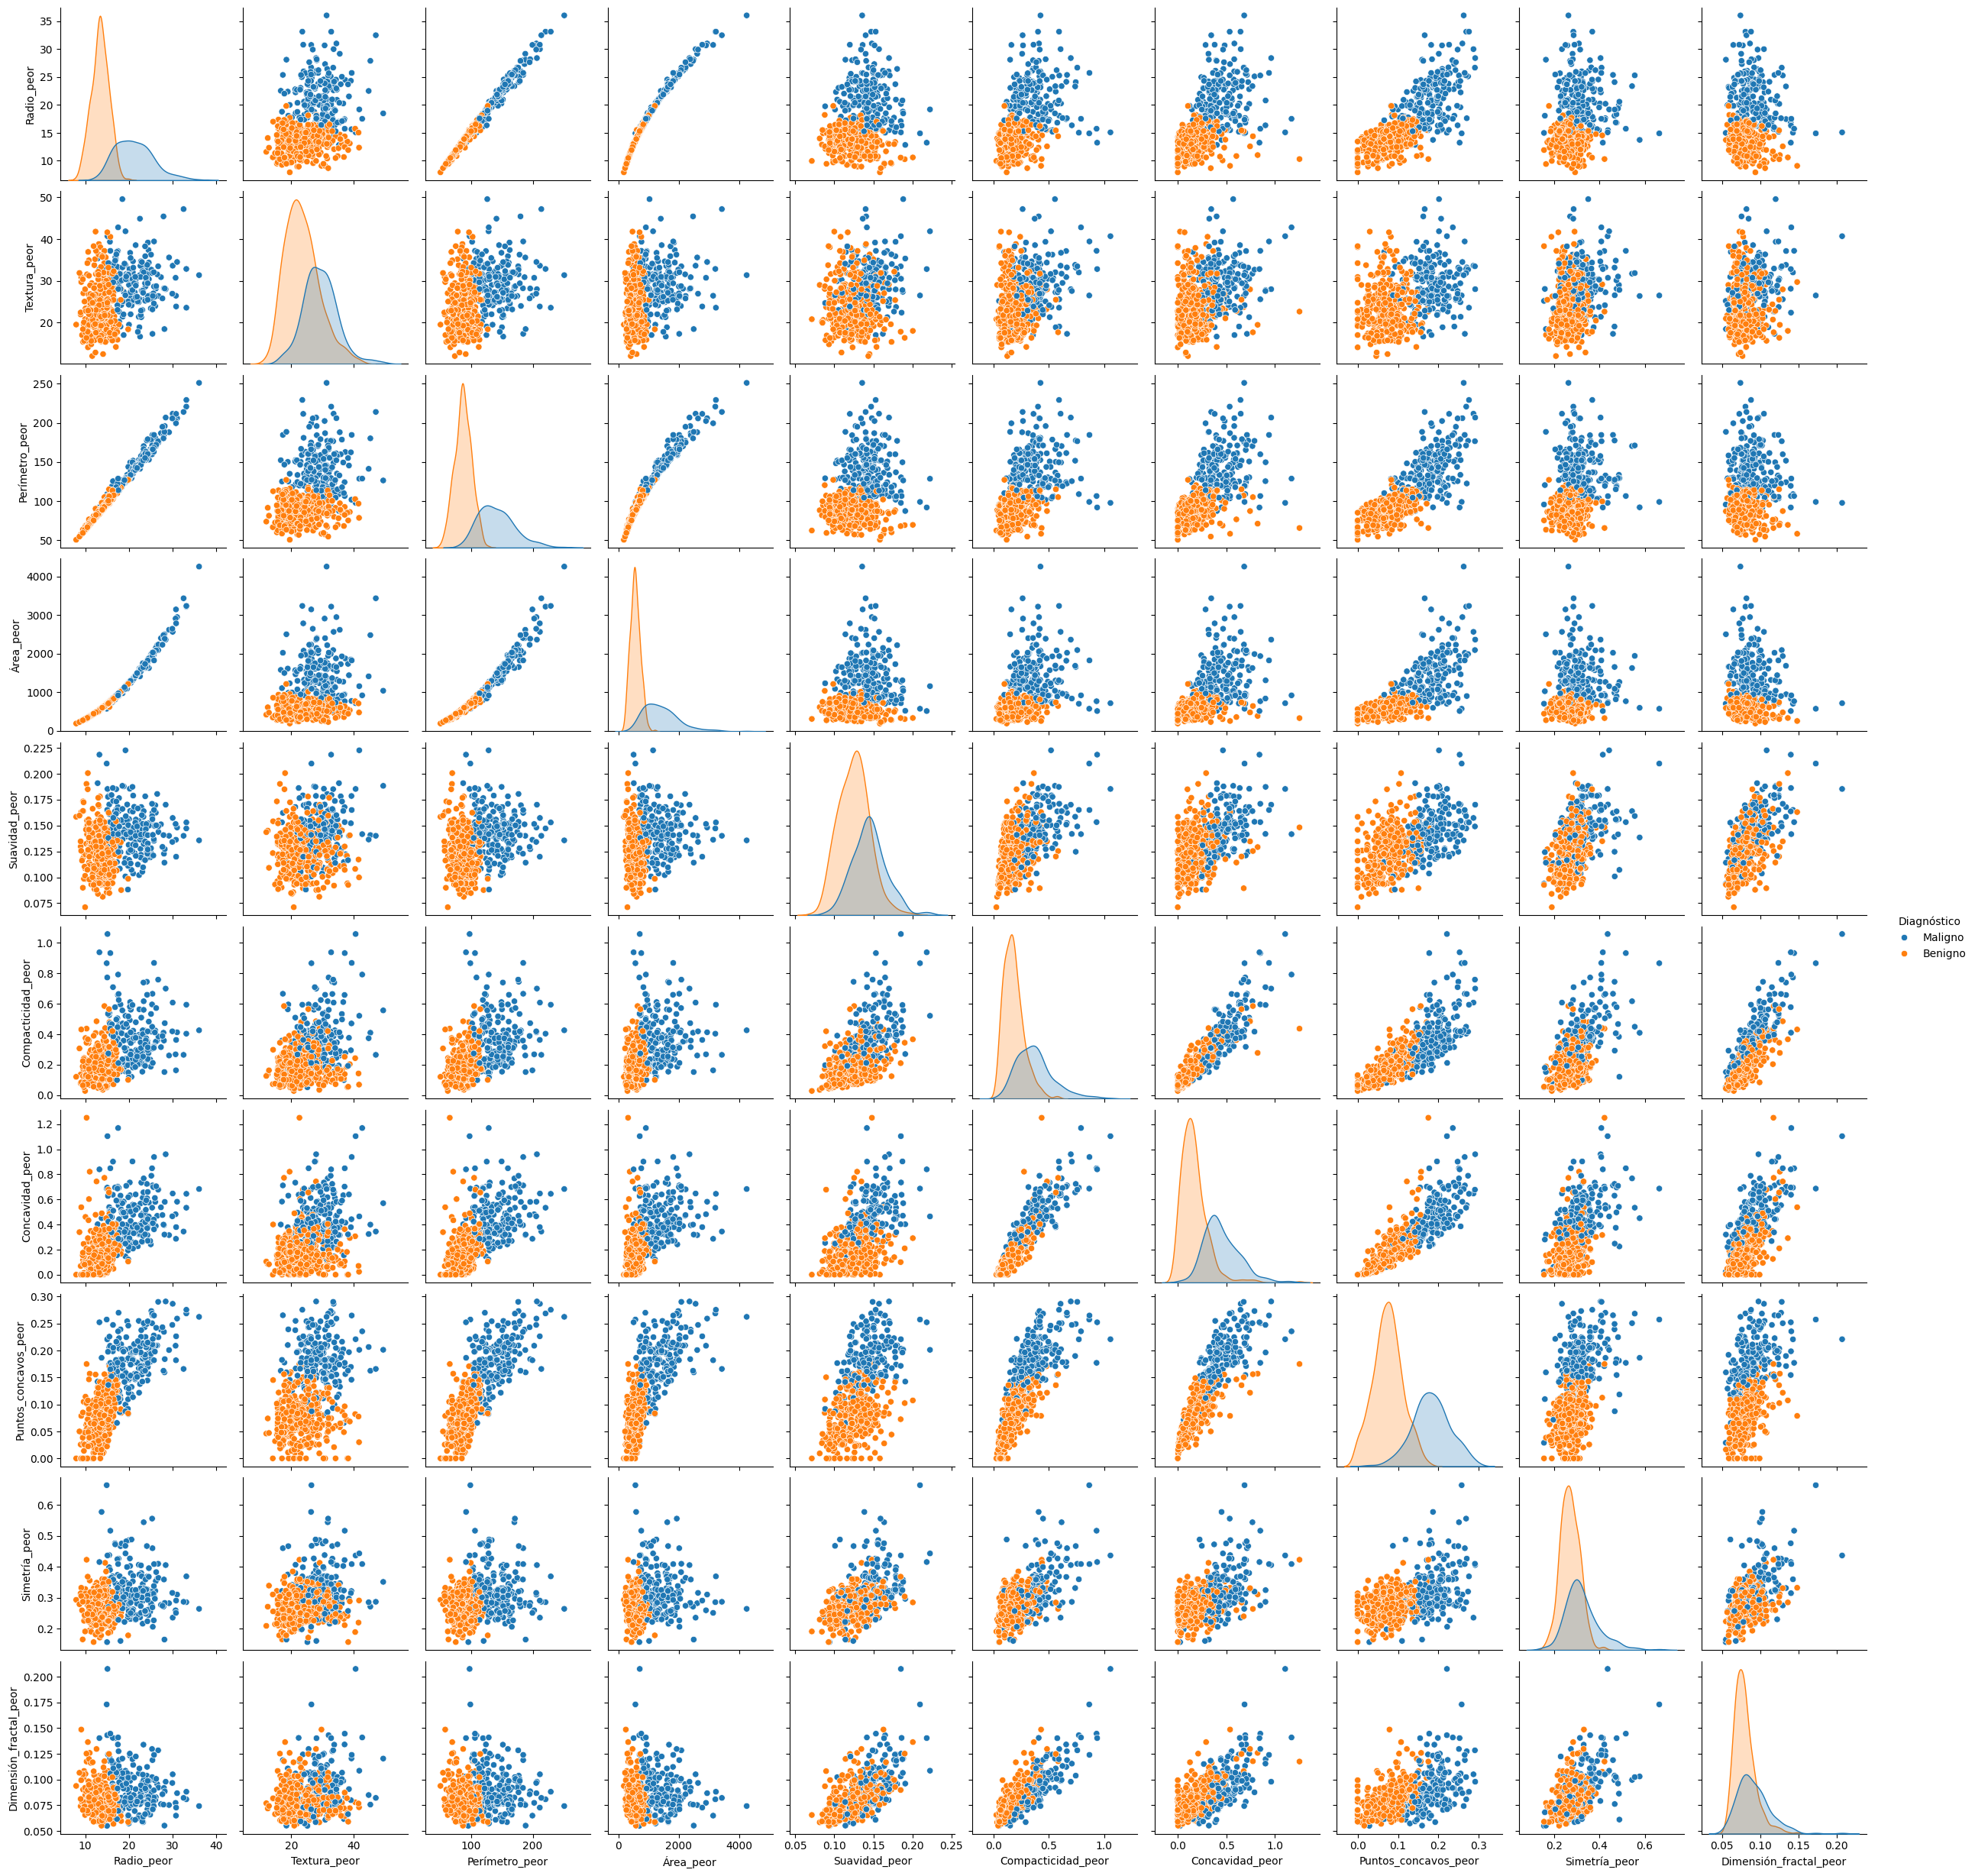

In [10]:
# Grafico de correlación
plt.figure(figsize=(10,6))
sns.pairplot(data=Data_Kaggle, hue="Diagnóstico")
plt.show()

### Datos Escalares

In [11]:
#Datos de escalamiento
Escalar = MinMaxScaler()
Data_Kaggle_Escalar = Escalar.fit_transform(Data_Kaggle_Int)

#DataFrame Datos escalamiento
Data_Kaggle_Escalar_DF = pd.DataFrame(Data_Kaggle_Escalar)

#Pasamos nombre de los campos al DF Escalar
Data_Kaggle_Escalar_DF.columns = Data_Kaggle_Int.columns
#Data_Kaggle_Escalar_DF


### Entrenamiento del modelo de regresión logistica

In [12]:
x = Data_Kaggle_Escalar_DF.drop("Diagnóstico", axis=1)
y = Data_Kaggle_Escalar_DF["Diagnóstico"].values

# Obtenemos Variables de entrenamiento
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.3, 
    random_state=42,
    stratify=y # Se Agrega para mejorar el modelo, estratifica los datos a partir de Diagnóstico
)

Modelo = LogisticRegression()
Modelo.fit(x_train, y_train)
Prediccion = Modelo.predict(x_test)

# Obtenemos el porentaje de exactitud de precisión del modelo
Exactitud = accuracy_score(y_test ,Prediccion)
print(f"Porcentaje de precisión del modelo: {Exactitud*100:.2f}%")

Porcentaje de precisión del modelo: 91.23%


### Evaluación y Caracteristicas del modelo

In [13]:
#Evaluación del modelo
Modelo.predict_proba(x_test)

#Caracteristicas
Modelo.feature_names_in_

pesos = pd.Series(Modelo.coef_[0], index=x.columns.values)
pesos_DF = pd.DataFrame({
    "Variable": x.columns.values,
    "Coeficiente": Modelo.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

In [14]:
pesos_DF["Color"] = pesos_DF["Coeficiente"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

fig = px.bar(
    pesos_DF,
    x="Variable",
    y="Coeficiente",
    color="Color",
    color_discrete_map={"Negativo": "darkred", "Positivo": "darkblue"},
    labels={"x":"Variables", "y":"Coeficiente"},
    title="Coeficientes del Modelo (Logistic Regression)"
)

fig.update_layout(width=890, height=900)

Estilos(fig)
fig.show()

### Matriz de confusión

In [16]:
Matriz_Confucion_II = confusion_matrix(y_test, Prediccion)

# Mostrar valores en consola
print(f"Verdaderos Negativos (VN): {Matriz_Confucion_II[0][0]} Personas que Sí tienen tumores benignos y el modelo dijo Sí tienen tumores benignos.")
print(f"Verdadero Positivo (VP): {Matriz_Confucion_II[1][1]} Personas que SÍ tienen tumores malignos y el modelo dijo SÍ tienen tumores malignos.")
print(f"Falso Positivos (FP): {Matriz_Confucion_II[0][1]} Personas que Sí tienen tumores benignos, pero el modelo dijo que SÍ tienen tumores malignos.")
print(f"Falso Negativo (FN): {Matriz_Confucion_II[1][0]} Personas que SÍ tienen tumores malignos, pero el modelo dijo que Sí tienen tumores benignos.")

# Heatmap con Plotly
fig = px.imshow(
    Matriz_Confucion_II,
    text_auto=True,
    color_continuous_scale="Blues",
    labels=dict(x="Predicciones", y="Verdaderos", color="Cantidad"),
    x=["Con tumores benignos (0)", "Con tumores Malignos (1)"],
    y=["Con tumores Benignos (0)", "Con tumores Malignos (1)"]
)

fig.update_layout(
    title="Matriz de Confusión",
    width=600,
    height=500
)

Estilos(fig)

fig.show()

Verdaderos Negativos (VN): 106 Personas que Sí tienen tumores benignos y el modelo dijo Sí tienen tumores benignos.
Verdadero Positivo (VP): 50 Personas que SÍ tienen tumores malignos y el modelo dijo SÍ tienen tumores malignos.
Falso Positivos (FP): 1 Personas que Sí tienen tumores benignos, pero el modelo dijo que SÍ tienen tumores malignos.
Falso Negativo (FN): 14 Personas que SÍ tienen tumores malignos, pero el modelo dijo que Sí tienen tumores benignos.
